This is a notebook for me to prepare my scripts for data processing and management. I'll be testing out some code to see what works.

In [8]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# without this, Numpy and Matplotlib and Librosa all try and activate this library and it crashes. This is a workaround that the error message sugests and warns heavily agian... Oh well!

In [9]:
import torchaudio.transforms as T
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [10]:
test_song = "Benson Boone - Mystical Magical.ogg"

In [11]:
y, sr = librosa.load(test_song, sr=41100, mono=True)

Plotting the waveform of the song to make sure it was loaded properly

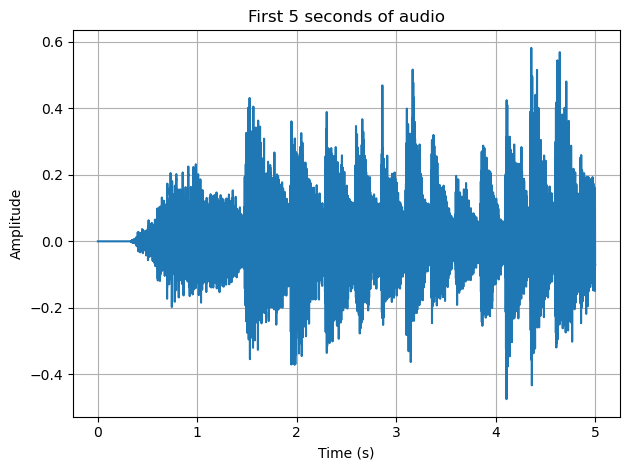

In [12]:
time = np.linspace(0, len(y) / sr, num=len(y))

# Plot waveform
seconds = 5
samples = sr * seconds
plt.plot(np.linspace(0, seconds, samples), y[:samples])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'First {seconds} seconds of audio')
plt.grid(True)
plt.tight_layout()
plt.show()

Great, it was loaded properly
Let's try making a spectrogram just with torch's built in feature

In [13]:
# here are some global parameters to play around with the spectrogram
n_fft_global = 2**12
win_length_global = 2**12
hop_length_global = 2**11
power_global = 2.0

In [14]:
def make_spectrogram(
        waveform,
        n_fft=2**11,
        win_length=2**11,
        hop_length=2**10,
        power=2.0
):
    spectrogram = T.Spectrogram(
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        power=power
    )
    return spectrogram(waveform)

In [15]:
y_torch = torch.tensor(y).unsqueeze(0)  # Add batch dimension

In [16]:
spec = make_spectrogram(y_torch, n_fft=n_fft_global, win_length=win_length_global, hop_length=hop_length_global, power=power_global)

In [17]:
spec.shape

torch.Size([1, 2049, 3327])

In [18]:
def plot_spectrogram(spec, sr, hop_length):

    S_db = librosa.power_to_db(spec.squeeze(0).numpy(), ref=np.max)  # remove channel dim and convert to dB

    # Plot
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Spectrogram (dB)")
    plt.tight_layout()

    plt.savefig(f"spectrogram_{win_length_global}.png", dpi=300, bbox_inches='tight')
    
    plt.show()



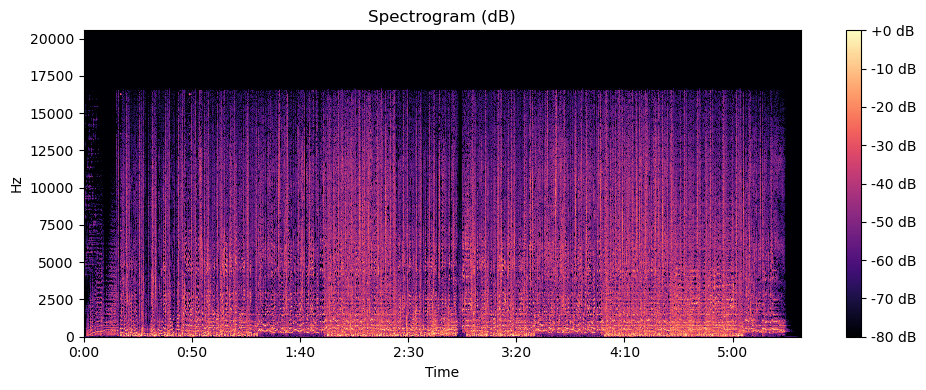

In [19]:
plot_spectrogram(spec = make_spectrogram(y_torch), sr=sr, hop_length=hop_length_global)

In [20]:
# here are some global parameters to play around with the spectrogram
n_fft_global = 2**10
win_length_global = 2**10
hop_length_global = win_length_global // 2
power_global = 2.0

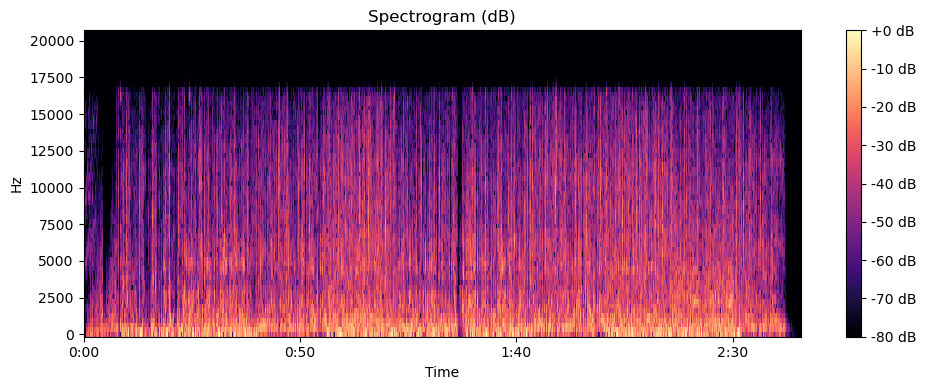

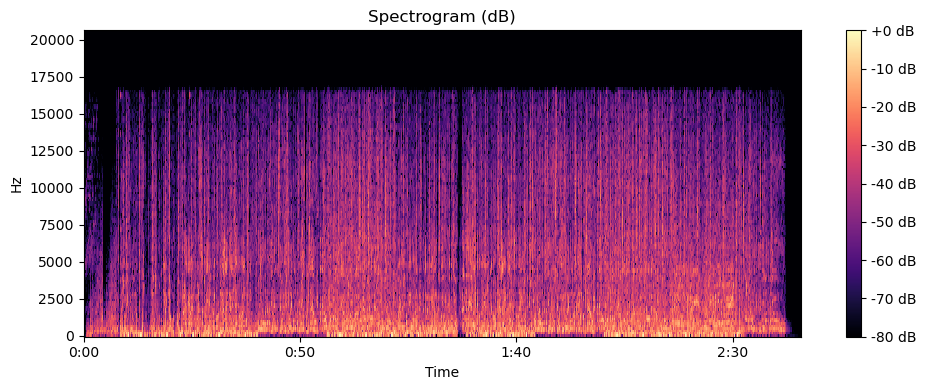

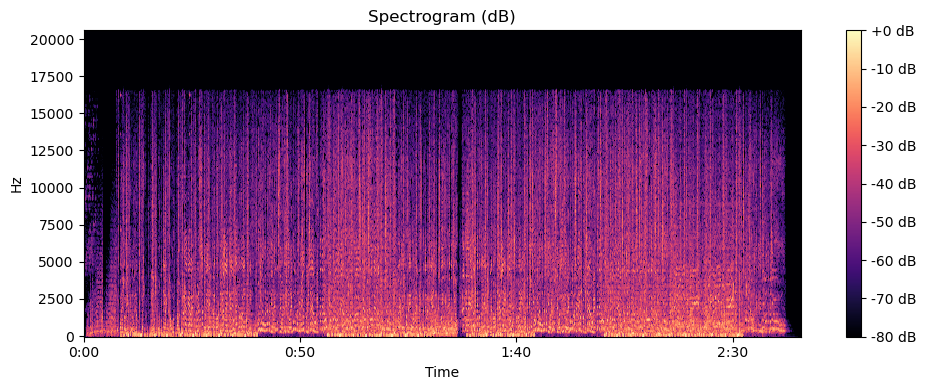

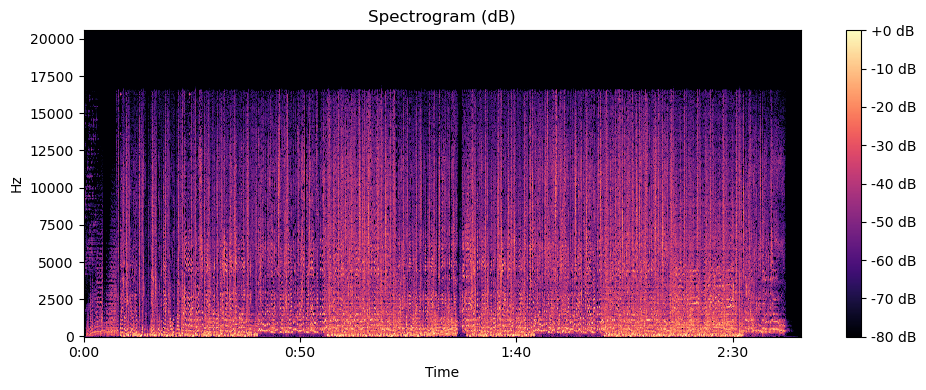

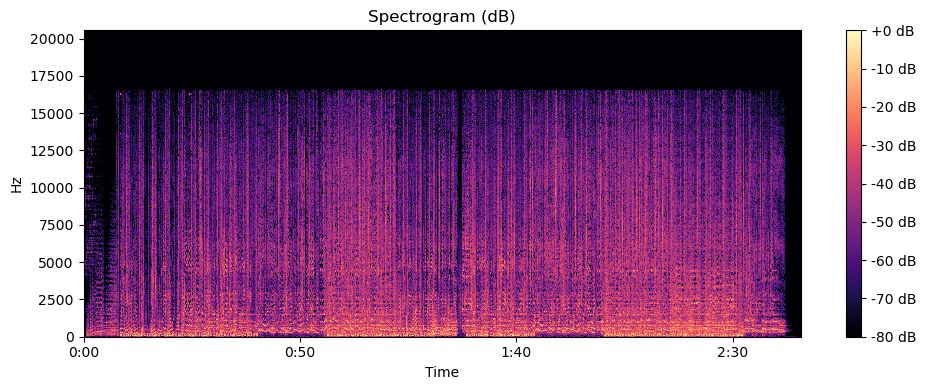

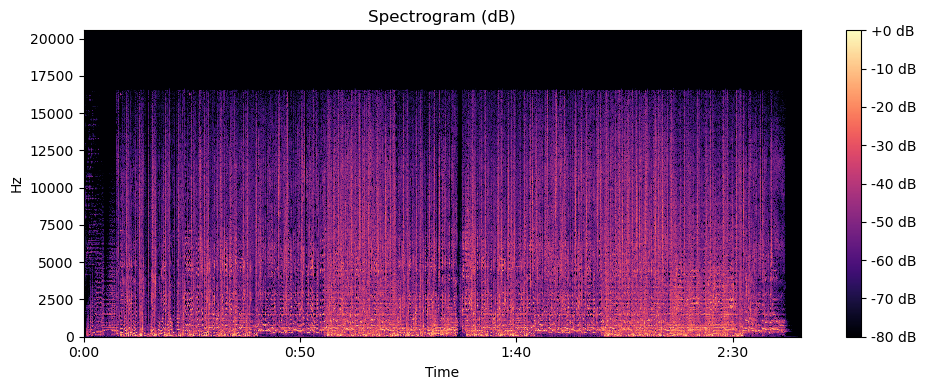

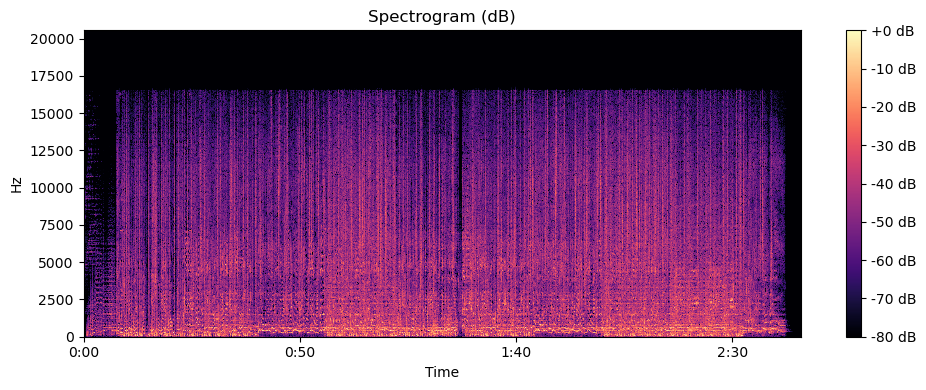

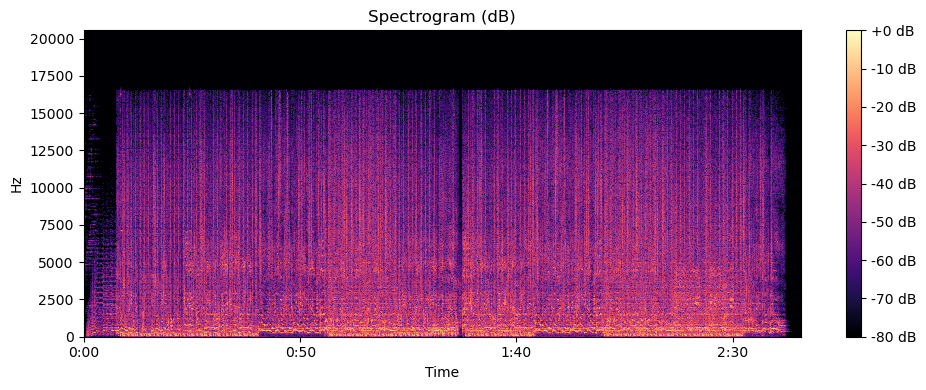

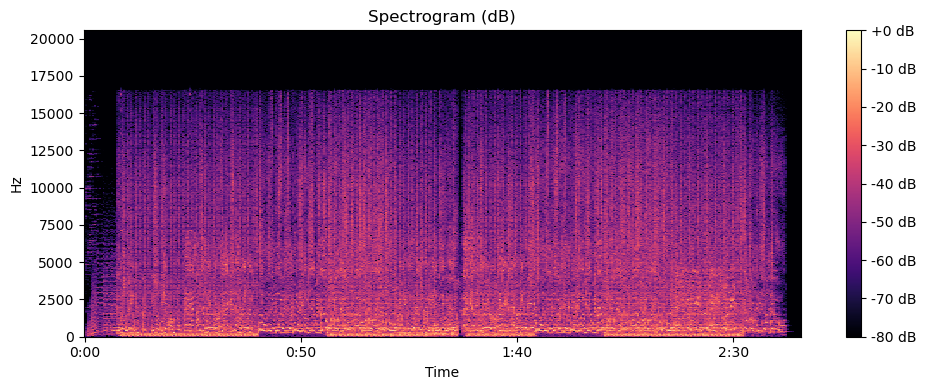

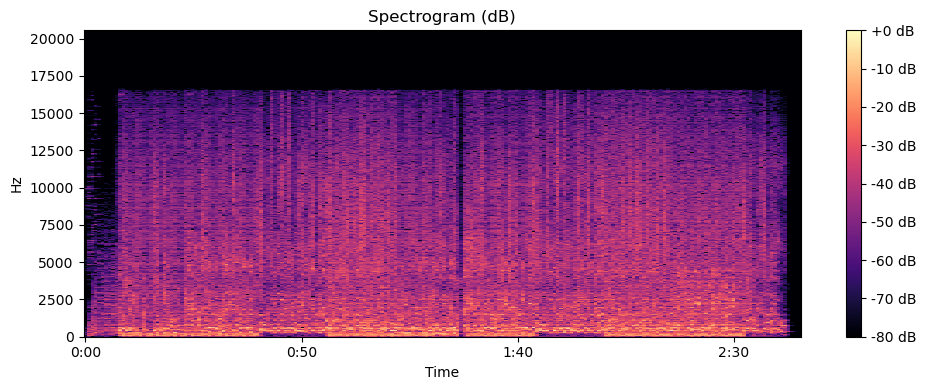

In [21]:
for i in range(7, 17):
    n_fft_global = 2**i
    win_length_global = 2**i
    hop_length_global = win_length_global // 2
    spec = make_spectrogram(y_torch, n_fft=n_fft_global, win_length=win_length_global, hop_length=hop_length_global, power=power_global)
    plot_spectrogram(spec, sr=sr, hop_length=hop_length_global)